### To make a complete system, first we make them in ipynb and later make corresponding python .py files for each

#### AI Tutor is a multi-agent agentic system that follows multi-agent architecture.

##### We add multiple specialized agents to the AI Tutor that works autonomouly parallely or sequentially based upon the requirements to reach/achieve the goal. Supervisor being at the top makes the goal into sub-goals and provide the sub-goal to corresponding agents based upon the specialization

##### All the necessary imports are:

In [1]:
from langchain_core.tools import tool
from langchain_tavily import TavilySearch
from langchain_groq import ChatGroq
from langchain_community.document_loaders import PyPDFLoader
from langchain_core.prompts import PromptTemplate, ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser, PydanticOutputParser
from pydantic import BaseModel, Field
from typing import Literal, TypedDict, Optional, List, Annotated
from langchain_ollama import OllamaEmbeddings
from langchain_nvidia_ai_endpoints import ChatNVIDIA
from langchain_core.messages import HumanMessage, SystemMessage, ToolMessage, AIMessage, BaseMessage
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.checkpoint.sqlite import SqliteSaver
import sqlite3
from langgraph.graph.message import add_messages
from langgraph.types import Command, Interrupt
from dotenv import load_dotenv
import os
import re
import json
import operator

c:\Users\Nitro\Desktop\Desk\AITutor\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [2]:
load_dotenv()

True

### Supervisor and Workers:- 

##### We need to make a supervisor agent where all the workers agent that are going to work and their use are given to the supervisor using prompt so that it can make reasoning and then handsoff the corresponding agent.

##### The supervisor should route the task to the corresponding agent in such a way that the whole task could be done by the agent in and no other agent's capable work should be given to the agent. Such prompt should be given to the supervisor agent.

##### Each agent will get the task that only belongs to it and then when the agent does its work then the agent will change the state due to which the supervisor can get all the changes done by the agent and go for the next job to delegate.

##### It's just like the Orchestrator.

### tools

In [3]:
llm = ChatGroq(
    api_key=os.getenv("api_key"),
        model="llama-3.3-70b-versatile"
)

# llm = ChatNVIDIA(
#   model="openai/gpt-oss-20b",
#   api_key="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", 
#   temperature=1,
#   top_p=1,
#   max_tokens=4096,
# )


# llm = ChatOllama(model = "llama3.2")

tavily_research_tool = TavilySearch(max_results=3, include_answer= True, search_depth= "advanced", auto_parameters=True)
tavily_research_tool.invoke({"query" : "What is llm?"})

{'query': 'What is llm?',
 'follow_up_questions': None,
 'answer': 'A large language model (LLM) is an AI system that generates and understands human language. It is trained on vast datasets to perform tasks like text generation and comprehension. LLMs use neural networks for efficient processing.',
 'images': [],
 'results': [{'url': 'https://ask.library.arizona.edu/faq/407985',
   'title': 'What is a large language model (LLM)?',
   'content': '## What is a large language model (LLM)?\n\nA large language model (LLM) is a type of artificial intelligence that can generate human language and perform related tasks. These models are trained on huge datasets, often containing billions of words. By analyzing all this data, the LLM learns patterns and rules of language, similar to the way a human learns to communicate through exposure to language. LLMs can perform various language tasks, such as answering questions, summarizing text, translating between languages, and writing content.\n\nSom

In [4]:
# making dictionary for each of the agents tool

# research agent
research_tools = [tavily_research_tool]
research_tools_by_name = {tool.name : tool for tool in research_tools}

# task_specific_agent
materials_tools = []
materials_tools_by_name = {tool.name : tool for tool in materials_tools}

#rag_agent
rag_tools = []
rag_tools_by_name = {tool.name : tool for tool in rag_tools}

# youtube_agent
youtube_tools = []
youtube_tools_by_name = {tool.name : tool for tool in youtube_tools}

### LLM for each agents with tools binded to it

In [5]:
llm = ChatGroq(model= os.getenv("model"), api_key=os.getenv("api_key"))
research_agent_with_tool =  llm.bind_tools([tavily_research_tool])
rag_agent_with_tool = llm.bind_tools(rag_tools)
youtube_agent_with_tool = llm.bind_tools(youtube_tools)
task_agent_with_tool = llm.bind_tools(materials_tools)


In [6]:
# BaseModels

class Task(BaseModel):
    '''contains information of each step of the plan'''
    id : int = Field(description="id of the step")
    goal : str = Field(description="goal that the user needs to reach after reding the task's answer")
    research_flag : bool = Field("True if research tool is required and False if not")

task_schema = PydanticOutputParser(pydantic_object=Task)

class Plan(BaseModel):
    '''list of plan'''
    plan : list[Task]

plan_schema = PydanticOutputParser(pydantic_object=Plan)

class Goal(BaseModel):
    '''contains the goal for the particualr agent with name of the agent'''
    # title : str = Field(description = "name or title based upon the user query")
    id : str = Field(description = "id of the agent in string")
    agent : Literal['Researcher', 'RAG', 'TaskSpecific', 'YoutubeAgent', 'END'] = Field(description="one specific agent that is to be choosen for the work")
    sub_goal : str = Field(description = "goal that is provided the to the specific one agent")

sub_goal_schema = PydanticOutputParser(pydantic_object=Goal)

class RAG_agent_type(BaseModel):
    pass


class Youtube_agent_type(BaseModel):
    pass


class Task_specific_type(BaseModel):
    pass


In [7]:
# Research Graph
class ResearchState(TypedDict):
    # Sub-goal given by the supervisor
    sub_goal : str
    
    # plan made by the researcher agent
    agent_plan : Annotated[list[Task], operator.add]

    # explaination done by agent (either toolMessage or the AiMessage)
    agent_explain : Annotated[list[str], operator.add]

    # key points covered by this agent
    key_points : Annotated[list[str], operator.add]


# MaterialGraph (Q/A_and_flashcards and study planner))
class MaterialsState(TypedDict):
    pass

class RAGState(TypedDict):
    pass

class YoutubeState(TypedDict):
    pass

# Main State
class State(TypedDict):
    goal : str
    title : str
    need_RAG : bool
    agent_id : Annotated[list[str], add_messages]
    Researcher : ResearchState
    YoutubeAgent : Youtube_agent_type
    TaskSpecific : Task_specific_type


In [20]:
def Planner(state : ResearchState):
    goal = state['sub_goal']
    # prompt = PromptTemplate(template="goal : {sub_goal} \n\n{format}", input_variables=['sub_goal'], partial_variables={"format" : task_schema.get_format_instructions()})
    prompt = ChatPromptTemplate.from_messages([
        ("system", """You as an excellent planner agent that can generate a beautiful productive plan to give to the worker agents to execute on the basis of your plan. Workers agents will explain based on you plan so make the plan good. 
         Total number of steps must be less than 7. \n

         ***RULE***
         research_flag should be True only if the step requires external research tool\n
         ***Structure***
         Just give me list of steps in the following JSON format:\n
        {plan}\n\n
         where each task is in the form of:\n
         {task}"""),
        ("human", "Goal : {goal}")]).partial(plan = plan_schema.get_format_instructions(), task = task_schema.get_format_instructions())
    chain = prompt | llm | plan_schema
    plan = chain.invoke({'goal' : goal}).plan
    print(plan)
    key_points = []
    agent_plan = []
    for step in plan:
        agent_plan.append({
            'id' : step.id,
            'goal' : step.goal,
            'research_flag' : step.research_flag
        })
        key_points.append(step.goal)
    print(agent_plan)
    return {'agent_plan' : agent_plan, 'key_points' : key_points}

In [21]:
Planner(ResearchState(sub_goal="trends in AI"))

[Task(id=1, goal='Identify current trends in AI', research_flag=True), Task(id=2, goal='Analyze recent developments in machine learning and deep learning', research_flag=True), Task(id=3, goal='Explore applications of AI in various industries such as healthcare, finance, and transportation', research_flag=True), Task(id=4, goal='Summarize key findings and insights on AI trends', research_flag=False), Task(id=5, goal='Provide recommendations for future research and development in AI', research_flag=False), Task(id=6, goal='Compile a report on AI trends and insights', research_flag=False)]
[{'id': 1, 'goal': 'Identify current trends in AI', 'research_flag': True}, {'id': 2, 'goal': 'Analyze recent developments in machine learning and deep learning', 'research_flag': True}, {'id': 3, 'goal': 'Explore applications of AI in various industries such as healthcare, finance, and transportation', 'research_flag': True}, {'id': 4, 'goal': 'Summarize key findings and insights on AI trends', 'resea

{'agent_plan': [{'id': 1,
   'goal': 'Identify current trends in AI',
   'research_flag': True},
  {'id': 2,
   'goal': 'Analyze recent developments in machine learning and deep learning',
   'research_flag': True},
  {'id': 3,
   'goal': 'Explore applications of AI in various industries such as healthcare, finance, and transportation',
   'research_flag': True},
  {'id': 4,
   'goal': 'Summarize key findings and insights on AI trends',
   'research_flag': False},
  {'id': 5,
   'goal': 'Provide recommendations for future research and development in AI',
   'research_flag': False},
  {'id': 6,
   'goal': 'Compile a report on AI trends and insights',
   'research_flag': False}],
 'key_points': ['Identify current trends in AI',
  'Analyze recent developments in machine learning and deep learning',
  'Explore applications of AI in various industries such as healthcare, finance, and transportation',
  'Summarize key findings and insights on AI trends',
  'Provide recommendations for future

In [10]:
def Researcher(state : ResearchState):
    plan = state['agent_plan']
    explaination = []
    prompt = ChatPromptTemplate.from_messages([
        ('system', """
    You are a **Research & Explanation Agent**.

    You will receive **one task at a time**. Your job is to produce content that directly satisfies the goal.
    Rules:
    - Focus only on the current task. Do not explain unrelated concepts.
    - Adapt explanation to goal type: definition, math, numeric example, summary, etc.
    - Output concise, relevant explanation. No forced headings, templates, or extra text.
    """),
        ('human', "task : {task}")
    ])
    for step in plan:
        print(step)
        if step['research_flag'] == True:
            # do the llm call with the research_flag
            output = research_agent_with_tool.invoke(step['goal'])
            if(not output.tool_calls):
                print(output.tool_calls or output.content)
            else:
                tool_recommended = output.tool_calls[0]
                tool_name = research_tools_by_name[tool_recommended['name']]
                tool_output = tool_name.invoke(tool_recommended['args'])['answer']
                print(tool_output)
                explaination.append(tool_output)
        else:
            chain = prompt | llm | StrOutputParser()
            # result = chain.invoke(step['goal'])
            message = HumanMessage(content=step['goal'])  # wrap goal
            result = chain.invoke([message])              
            print(result)
            explaination.append(result)

    return {'agent_explain' : explaination}

In [11]:
Researcher({'agent_plan': [{'id': 1,
   'goal': 'Identify current trends in AI',
   'research_flag': True},
  {'id': 2,
   'goal': 'Analyze recent developments in AI research',
   'research_flag': True},
  {'id': 3,
   'goal': 'Explore applications of AI in various industries',
   'research_flag': False},
  {'id': 4,
   'goal': 'Summarize key findings and insights on AI trends',
   'research_flag': False},
  {'id': 5,
   'goal': 'Provide recommendations for future AI research and development',
   'research_flag': False},
  {'id': 6,
   'goal': 'Present the final report on AI trends',
   'research_flag': False}]})

{'id': 1, 'goal': 'Identify current trends in AI', 'research_flag': True}
Current AI trends include generative AI, multimodal AI, and increased workplace automation. Quantum computing and environmental sustainability are also emerging areas.
{'id': 2, 'goal': 'Analyze recent developments in AI research', 'research_flag': True}
Recent developments in AI research include the release of several new AI models by Chinese tech companies, with MiniMax's M2.5 model gaining significant attention for its performance and lower price compared to competitors like DeepSeek and Anthropic's Claude. Additionally, AI's role in life sciences is evolving from supporting isolated tasks to becoming essential collaborators embedded across the research lifecycle, fundamentally reshaping how innovation happens in healthcare and beyond.
{'id': 3, 'goal': 'Explore applications of AI in various industries', 'research_flag': False}
Artificial intelligence (AI) has numerous applications across various industries, t

{'agent_explain': ['Current AI trends include generative AI, multimodal AI, and increased workplace automation. Quantum computing and environmental sustainability are also emerging areas.',
  "Recent developments in AI research include the release of several new AI models by Chinese tech companies, with MiniMax's M2.5 model gaining significant attention for its performance and lower price compared to competitors like DeepSeek and Anthropic's Claude. Additionally, AI's role in life sciences is evolving from supporting isolated tasks to becoming essential collaborators embedded across the research lifecycle, fundamentally reshaping how innovation happens in healthcare and beyond.",
  "Artificial intelligence (AI) has numerous applications across various industries, transforming the way businesses operate and deliver value to customers. Here are some examples:\n\n1. **Healthcare**: AI assists in disease diagnosis, personalized medicine, and patient data analysis. It helps doctors identify

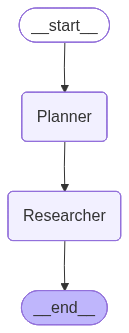

In [12]:
researchGraph = StateGraph(ResearchState)

researchGraph.add_node("Planner", Planner)
researchGraph.add_node("Researcher", Researcher)

researchGraph.add_edge(START, "Planner")
researchGraph.add_edge("Planner", "Researcher")
researchGraph.add_edge("Researcher", END)

ResearcherSubGraph = researchGraph.compile()
ResearcherSubGraph

In [22]:
ResearcherSubGraph.invoke({'sub_goal' : "explain self sttention clearly"})

[Task(id=1, goal='Introduce the concept of self-attention', research_flag=False), Task(id=2, goal='Explain the motivation behind self-attention in transformer models', research_flag=False), Task(id=3, goal='Describe the self-attention mechanism with a simple example', research_flag=False), Task(id=4, goal='Highlight the key components of self-attention, including query, key, and value vectors', research_flag=False), Task(id=5, goal='Discuss the benefits of self-attention, such as parallelization and reduced computational complexity', research_flag=False), Task(id=6, goal='Provide a visual illustration or analogy to help solidify understanding of self-attention', research_flag=False)]
[{'id': 1, 'goal': 'Introduce the concept of self-attention', 'research_flag': False}, {'id': 2, 'goal': 'Explain the motivation behind self-attention in transformer models', 'research_flag': False}, {'id': 3, 'goal': 'Describe the self-attention mechanism with a simple example', 'research_flag': False}, {

{'sub_goal': 'explain self sttention clearly',
 'agent_plan': [{'id': 1,
   'goal': 'Introduce the concept of self-attention',
   'research_flag': False},
  {'id': 2,
   'goal': 'Explain the motivation behind self-attention in transformer models',
   'research_flag': False},
  {'id': 3,
   'goal': 'Describe the self-attention mechanism with a simple example',
   'research_flag': False},
  {'id': 4,
   'goal': 'Highlight the key components of self-attention, including query, key, and value vectors',
   'research_flag': False},
  {'id': 5,
   'goal': 'Discuss the benefits of self-attention, such as parallelization and reduced computational complexity',
   'research_flag': False},
  {'id': 6,
   'goal': 'Provide a visual illustration or analogy to help solidify understanding of self-attention',
   'research_flag': False}],
 'agent_explain': ['Self-attention is a mechanism used in deep learning, particularly in transformer-based architectures. It allows a model to attend to different parts

In [14]:
def MiniSuervisor(state : MaterialsState):
    pass

def StudyPlanner(state : MaterialsState):
    pass

def QAandFlashCards(state : MaterialsState):
    pass

def SubAgentSelection(state : MaterialsState):
    if 1:
        return "QAandFlashCards"
    
    elif 2:
        return "StudyPlanner"
    
    elif 3:
        return "END"

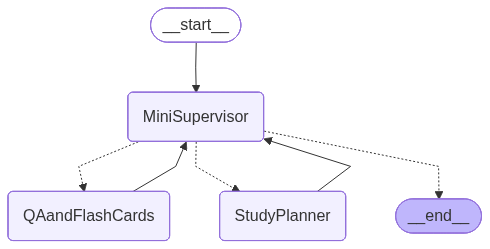

In [15]:
subGraph = StateGraph(State)
subGraph.add_node("MiniSupervisor", MiniSuervisor)
subGraph.add_node("StudyPlanner", StudyPlanner)
subGraph.add_node("QAandFlashCards", QAandFlashCards)

subGraph.add_edge(START, "MiniSupervisor")
subGraph.add_conditional_edges("MiniSupervisor", SubAgentSelection,{"QAandFlashCards" : "QAandFlashCards", "StudyPlanner" : "StudyPlanner"})
subGraph.add_edge("QAandFlashCards", "MiniSupervisor")
subGraph.add_edge("StudyPlanner", "MiniSupervisor")
subGraph.add_edge("MiniSupervisor", END)

subSystem = subGraph.compile()

subSystem

In [35]:
# FOR THE SUPERVISOR NODE
def Supervisor(state : State):
    goal = state['goal']
    researcher = state.get('Researcher', {}).get("key_points", [])
    agent_id = state.get('agent_id', [])
    print("Already used agents :", agent_id)
    print(goal)
    print(researcher)
    prompt = ChatPromptTemplate([
        ('system', """You are a supervisor agent for an AI Tutor and you have a bunch of specialized agents:\n\n
         ****Specialized agents(worker agents) id and their speciality****
         1 --> Researcher : Research on the topics (research that required llm knowledge and research tools)
         5 --> END : If no any agents is required now.\n\n
        
         Now you have to choose one of the above agents based upon the user query and agent specialization/use. \n\n

         ****Specialized agents(worker agents) name and their work till now*****
         Researcher : {researcher_work}
         
         Very important Note : If there is [] with no elements in any of the agent, that means the agent hasn't been used yet. \n\n
         
         ****ALready Used Agents****
         Dont use the agents with the following id:
         {agent_id}

         ****Structure****
    
         To provide the specific agent you have to return the goal in the following structure\n

         {format}\n\n

        ****Rules****
         
         - Don't use already used agents
         - Only provide goal to the specialized agent goal when the query seems to demand.
         - Depending upon the user query, its meaning(as you are Tutor) and work done by workers till now, you must call only the required agent at a time,
         - Dont use the used agent twice.

         """),
        ('human', "Goal/Query from user : {goal}")
    ]).partial(format = sub_goal_schema.get_format_instructions(), researcher_work  = researcher)
    # Generate the title for it
    chain = prompt | llm | sub_goal_schema
    response = chain.invoke({'goal' : goal, 'agent_id' : agent_id})
    print('Supervisor Completed ✅')
    print(response.agent)
    return {'agent_id' : [response.id], response.agent : {'sub_goal' : response.sub_goal}}

In [37]:
Supervisor(State(goal="Self-Attention"))

Already used agents : []
Self-Attention
[]
Supervisor Completed ✅
Researcher


{'agent_id': ['1'],
 'Researcher': {'sub_goal': 'Provide a detailed explanation of Self-Attention, including its definition, how it works, its applications, and its significance in AI and NLP.'}}

In [25]:
# FOR THE RESEARCH NODE
# it should be complex as its job is not only to extract one knowledge but many aspects like what, how, why, when, exmaples, mechanism etc.
def Researcher(state : State):
    sub_goal = state['Researcher']['sub_goal']
    print("Researcher agent's Goal: ",sub_goal)
    response = ResearcherSubGraph.invoke({'sub_goal' : sub_goal})
    print(response)
    print('Research Completed ✅')
    return {'Researcher' : {
        'sub_goal' : response['sub_goal'],
        'agent_plan' : response['agent_plan'],
        'agent_explain' : response['agent_explain'],
        'key_points' : response['key_points']
    }}

In [26]:
Researcher(State(Researcher= {
    'sub_goal' : "Self Attention",
}))

Researcher agent's Goal:  Self Attention
[Task(id=1, goal='Understand the concept of Self Attention', research_flag=False), Task(id=2, goal='Explain the architecture of Self Attention mechanism', research_flag=True), Task(id=3, goal='Describe the role of Query, Key, and Value matrices in Self Attention', research_flag=False), Task(id=4, goal='Discuss the applications of Self Attention in deep learning models', research_flag=True), Task(id=5, goal='Implement a simple Self Attention mechanism using a programming language', research_flag=False), Task(id=6, goal='Evaluate the performance of Self Attention in a specific task', research_flag=True)]
[{'id': 1, 'goal': 'Understand the concept of Self Attention', 'research_flag': False}, {'id': 2, 'goal': 'Explain the architecture of Self Attention mechanism', 'research_flag': True}, {'id': 3, 'goal': 'Describe the role of Query, Key, and Value matrices in Self Attention', 'research_flag': False}, {'id': 4, 'goal': 'Discuss the applications of 

{'Researcher': {'sub_goal': 'Self Attention',
  'agent_plan': [{'id': 1,
    'goal': 'Understand the concept of Self Attention',
    'research_flag': False},
   {'id': 2,
    'goal': 'Explain the architecture of Self Attention mechanism',
    'research_flag': True},
   {'id': 3,
    'goal': 'Describe the role of Query, Key, and Value matrices in Self Attention',
    'research_flag': False},
   {'id': 4,
    'goal': 'Discuss the applications of Self Attention in deep learning models',
    'research_flag': True},
   {'id': 5,
    'goal': 'Implement a simple Self Attention mechanism using a programming language',
    'research_flag': False},
   {'id': 6,
    'goal': 'Evaluate the performance of Self Attention in a specific task',
    'research_flag': True}],
  'agent_explain': ['Self-attention is a mechanism used in deep learning models, particularly in transformer architectures. It allows the model to attend to different parts of the input sequence simultaneously and weigh their importan

In [27]:
def YoutubeVideos(state : State):
    pass

In [28]:
# FOR THE YOUTUBEVIDEOS NODE
def Materials(state : State):
    # We make subgraph as it will contain multiple agents in side the TaskSpecific agent:
    # Sub-Supervisor
    # Worker Agents:
        # Q/A and FlashCards
        # StudyPlanner
    # All agents will have same tool as not needed much
    pass

In [29]:
# FOR THE RAG AGENT
def RAG(state : State):
    # we have retriever that is used to retrieve the corresponding queries asnwer from the document
    pass

In [30]:
# at the end when all the task are completed then all the results from each agent are synthesized into proper format
def Synthesizer(state : State):
    print("Synthesizer ✅")

    return {}
    # At last synthesize the whole blog/goal that are broken down and submitted to all the agents into one single organized form

In [31]:
def AgentSelection(state : State):
    agent_id = int(state['agent_id'][-1].content)
    print(type(agent_id))
    print("next ---->", agent_id)
    if agent_id == 1:
        return "Researcher"
    elif agent_id == 2: 
        return "RAG"
    elif agent_id == 3:
        return "TaskSpecific"
    elif agent_id == 4:
        return "YoutubeAgent"
    else:
        return "Synthesizer"

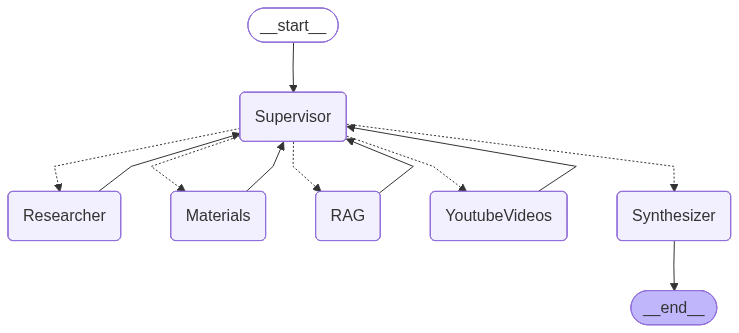

In [38]:
graph = StateGraph(State)
graph.add_node("Supervisor", Supervisor)
graph.add_node("Researcher", Researcher)
graph.add_node("Materials", Materials)    
graph.add_node("RAG", RAG)
graph.add_node("YoutubeVideos", YoutubeVideos)
graph.add_node("Synthesizer", Synthesizer)

graph.add_edge(START, "Supervisor")
graph.add_conditional_edges("Supervisor", AgentSelection, {"Researcher" : "Researcher", "RAG" : "RAG", "YoutubeVideos" : "YoutubeVideos", "Materials" : "Materials", "Synthesizer" : "Synthesizer"})
graph.add_edge("Researcher", "Supervisor")
graph.add_edge("RAG", "Supervisor")
graph.add_edge("Materials", "Supervisor")
graph.add_edge("YoutubeVideos", "Supervisor")
graph.add_edge("Synthesizer", END)

MainGraph = graph.compile()

MainGraph



In [39]:
MainGraph.invoke({'goal' : "Self-attention"})

Already used agents : []
Self-attention
[]
Supervisor Completed ✅
Researcher
<class 'int'>
next ----> 1
Researcher agent's Goal:  Research and provide information on self-attention, particularly its application in deep learning and natural language processing.
[Task(id=1, goal='Understand the concept of self-attention and its significance in deep learning', research_flag=True), Task(id=2, goal='Explore the application of self-attention in natural language processing', research_flag=True), Task(id=3, goal='Investigate the use of self-attention in popular deep learning models such as Transformers', research_flag=True), Task(id=4, goal='Gather information on the benefits and limitations of using self-attention in deep learning and NLP', research_flag=True), Task(id=5, goal='Compile and summarize the findings on self-attention and its applications', research_flag=False)]
[{'id': 1, 'goal': 'Understand the concept of self-attention and its significance in deep learning', 'research_flag': Tr

{'goal': 'Self-attention',
 'agent_id': [HumanMessage(content='1', additional_kwargs={}, response_metadata={}, id='06661797-43d2-4db3-bfec-0005983aa3ff'),
  HumanMessage(content='5', additional_kwargs={}, response_metadata={}, id='a7420461-b691-4252-9e8a-069ba102a215')],
 'Researcher': {'sub_goal': 'Research and provide information on self-attention, particularly its application in deep learning and natural language processing.',
  'agent_plan': [{'id': 1,
    'goal': 'Understand the concept of self-attention and its significance in deep learning',
    'research_flag': True},
   {'id': 2,
    'goal': 'Explore the application of self-attention in natural language processing',
    'research_flag': True},
   {'id': 3,
    'goal': 'Investigate the use of self-attention in popular deep learning models such as Transformers',
    'research_flag': True},
   {'id': 4,
    'goal': 'Gather information on the benefits and limitations of using self-attention in deep learning and NLP',
    'research

In [ ]:
output = research_agent_with_tool.invoke("What is AI")
output.tool_calls

[]

In [ ]:
output

AIMessage(content='AI stands for Artificial Intelligence. It refers to the simulation of human intelligence in machines that are programmed to think and learn like humans. The term can also be applied to any machine that exhibits traits associated with a human mind such as learning and problem-solving.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 51, 'prompt_tokens': 2104, 'total_tokens': 2155, 'completion_time': 0.115233592, 'completion_tokens_details': None, 'prompt_time': 0.062127013, 'prompt_tokens_details': None, 'queue_time': 0.044145027, 'total_time': 0.177360605}, 'model_name': 'meta-llama/llama-4-scout-17b-16e-instruct', 'system_fingerprint': 'fp_79da0e0073', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cfd0f-5e5b-7f42-a282-2900cb69783f-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 2104, 'output_tokens': 51, 'total_tokens': 2155})